set up the necessary imports and load the data:

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Loading the dataset
data = pd.read_csv("data/diabetes.csv")

# Splitting features and target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# data is split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

size of the dataset

In [4]:
# Get the number of rows and columns in the dataset
dataset_size = data.shape
print(f"The dataset contains {dataset_size[0]} rows and {dataset_size[1]} columns.")

The dataset contains 768 rows and 9 columns.


Number of features and classes

In [10]:
num_features = data.shape[1] - 1
num_classes = data['Outcome'].nunique()
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Number of features: 8
Number of classes: 2


Feature datatypes

In [6]:
print(data.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Running the Multi-layer perceptron with different solver parameters:

In [7]:
solvers = ['lbfgs', 'sgd', 'adam']
for solver in solvers:
    mlp = MLPClassifier(solver=solver, random_state=42, max_iter=1000)
    start_time = time.time()
    # Training the mlp model
    mlp.fit(X_train_scaled, y_train)
    # Calculate the training time
    train_time = time.time() - start_time
    # test set prediction
    y_pred = mlp.predict(X_test_scaled)
    # Get Accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Solver: {solver}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Training time: {train_time:.4f} seconds")
    print(classification_report(y_test, y_pred))
    print("----------------------------")

Solver: lbfgs
Accuracy: 0.6429
Training time: 0.3170 seconds
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        99
           1       0.50      0.53      0.51        55

    accuracy                           0.64       154
   macro avg       0.61      0.62      0.62       154
weighted avg       0.65      0.64      0.64       154

----------------------------
Solver: sgd
Accuracy: 0.7597
Training time: 3.4591 seconds
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

----------------------------
Solver: adam
Accuracy: 0.7208
Training time: 2.4554 seconds
              precision    recall  f1-score   support

           0       0.77      0.80      0.79        99

Varying the alpha parameter of the Multi-layer perceptron

Alpha: 0.0001, Accuracy: 0.7208
Alpha: 0.001, Accuracy: 0.7208
Alpha: 0.01, Accuracy: 0.7208
Alpha: 0.1, Accuracy: 0.7273
Alpha: 1, Accuracy: 0.7792
Alpha: 10, Accuracy: 0.6688


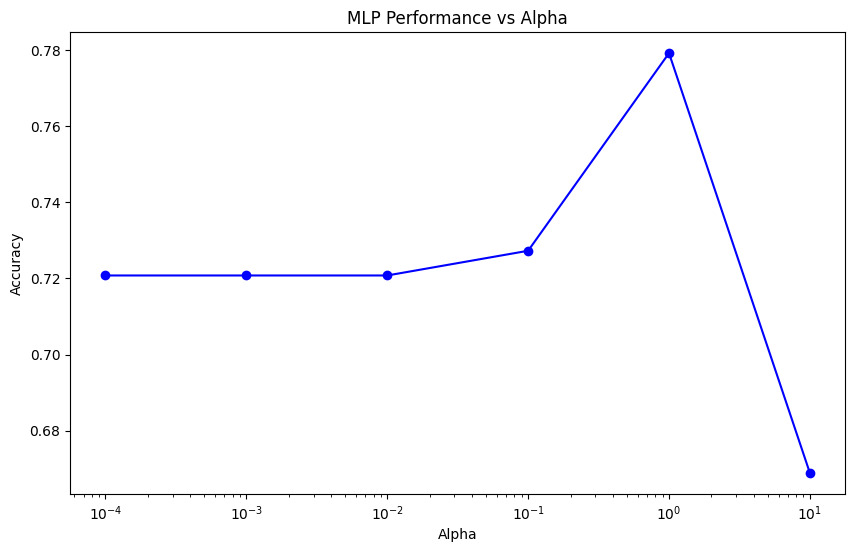

In [9]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
accuracies = []

for alpha in alphas:
    mlp = MLPClassifier(solver='adam', alpha=alpha, random_state=42, max_iter=1000)
    # Training the mlp model
    mlp.fit(X_train_scaled, y_train)
    # test set prediction
    y_pred = mlp.predict(X_test_scaled)
    # Get Accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    # Store result
    accuracies.append(accuracy)
    print(f"Alpha: {alpha}, Accuracy: {accuracy:.4f}")

# Plot graph (MLP performance vs Alpha)
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, accuracies, 'bo-')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('MLP Performance vs Alpha')
plt.savefig("images/alpha_vs_accuracy.png", dpi=300)
plt.show()

Comparing training times of SVM and Logistic Regression:

In [ ]:
# SVM training time measurement
svm = SVC(kernel='rbf', random_state=42)
start_time = time.time()
svm.fit(X_train_scaled, y_train)
svm_train_time = time.time() - start_time

# Logistic Regression training time measurement
lr = LogisticRegression(random_state=42)
start_time = time.time()
lr.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time

# Print training time
print(f"SVM training time: {svm_train_time:.4f} seconds")
print(f"Logistic Regression training time: {lr_train_time:.4f} seconds")

SVM training time: 0.0189 seconds
Logistic Regression training time: 0.0050 seconds


Correlation Heatmap Between Features

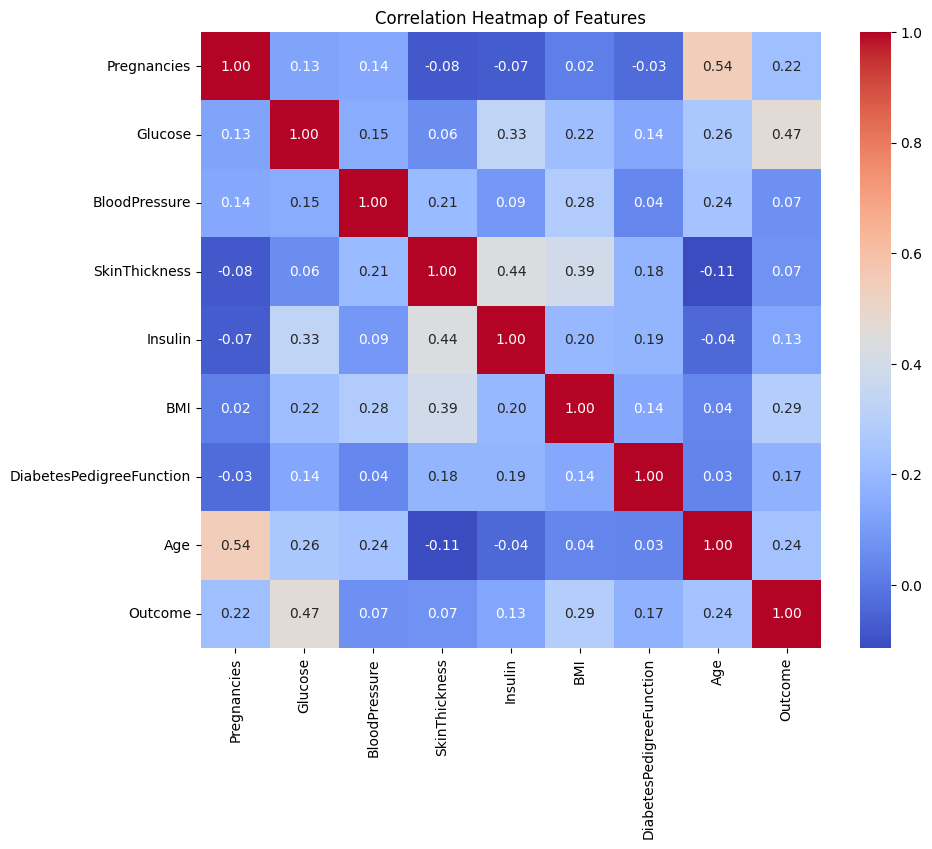

In [ ]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.savefig("images/correlation_heatmap.png", dpi=300)
plt.show()


Implementing PCA (Principal Component Analysis)

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 components
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train Logistic Regression on PCA-transformed data
log_reg_pca = LogisticRegression(random_state=42)
log_reg_pca.fit(X_train_pca, y_train)

# Evaluate the model
y_pred_pca = log_reg_pca.predict(X_test_pca)
print("Logistic Regression with PCA:")
print(classification_report(y_test, y_pred_pca))


Logistic Regression with PCA:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78        99
           1       0.61      0.51      0.55        55

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



Implementing FLD (Fisher Linear Discriminant)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

# Train Logistic Regression on LDA-transformed data
log_reg_lda = LogisticRegression(random_state=42)
log_reg_lda.fit(X_train_lda, y_train)

# Evaluate the model
y_pred_lda = log_reg_lda.predict(X_test_lda)
print("Logistic Regression with LDA:")
print(classification_report(y_test, y_pred_lda))


Logistic Regression with LDA:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



Implementing Feature Selection Techniques Method 1: Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE


# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Initialize RFE with the Logistic Regression model
rfe = RFE(log_reg, n_features_to_select=5)  # Selecting the top 5 features

# Fit RFE
rfe.fit(X_train_scaled, y_train)

# Transform the dataset
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

# Train Logistic Regression on the selected features
log_reg_rfe = LogisticRegression(random_state=42)
log_reg_rfe.fit(X_train_rfe, y_train)

# Make predictions and report results
y_pred_rfe = log_reg_rfe.predict(X_test_rfe)
print("Logistic Regression with RFE:")
print(classification_report(y_test, y_pred_rfe))

print("\nRFE selected features:")
selected_features_rfe = X.columns[rfe.support_]
print(selected_features_rfe.tolist())


Logistic Regression with RFE:
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        99
           1       0.59      0.64      0.61        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.72       154


RFE selected features:
['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age']


Method 2: SelectKBest

In [ ]:
from sklearn.feature_selection import SelectKBest,f_classif

# Initialize SelectKBest, selecting top 5 features
skb = SelectKBest(f_classif, k=5)

# Fit SelectKBest
X_train_skb = skb.fit_transform(X_train_scaled, y_train)
X_test_skb = skb.transform(X_test_scaled)

# Train Logistic Regression on the selected features
log_reg_skb = LogisticRegression(random_state=42)
log_reg_skb.fit(X_train_skb, y_train)

# Make predictions and report results
y_pred_skb = log_reg_skb.predict(X_test_skb)
print("Logistic Regression with SelectKBest:")
print(classification_report(y_test, y_pred_skb))

print("\nSelectKBest selected features:")
selected_features = X.columns[skb.get_support()]
print(selected_features.tolist())


Logistic Regression with SelectKBest:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


SelectKBest selected features:
['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']


Reporting precision, recall, F1 score, and accuracy of each classifier.

In [ ]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize classifiers
mlp = MLPClassifier(random_state=42)
svm = SVC(random_state=42)
log_reg = LogisticRegression(random_state=42)

# Train and evaluate MLP
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
print("MLP Classifier:")
print(classification_report(y_test, y_pred_mlp))

# Train and evaluate SVM
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("\nSVM Classifier:")
print(classification_report(y_test, y_pred_svm))

# Train and evaluate Logistic Regression
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
print("\nLogistic Regression Classifier:")
print(classification_report(y_test, y_pred_log_reg))


MLP Classifier:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154


SVM Classifier:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


Logistic Regression Classifier:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
